In [1]:
# This library helps us handle imbalanced data
!pip install imbalanced-learn

In [2]:
# Used to work with data (tables like Excel)
import pandas as pd

# Used for numerical operations
import numpy as np

# Used for graphs and visualization
import matplotlib.pyplot as plt

# Used to split data into training and testing
from sklearn.model_selection import train_test_split

# Used to evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Used to handle imbalanced dataset
from imblearn.over_sampling import SMOTE

In [9]:
# ---------------------------------------------
# STEP 1: LOAD DATA
# ---------------------------------------------

df = pd.read_csv('creditcard.csv')
# Remove missing values -

# Check if there are any missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Drop rows where target (Class) is NaN
df = df.dropna(subset=['Class'])

# Optional: reset index after dropping rows
df = df.reset_index(drop=True)

# Check again
print("Missing values after cleaning:\n", df.isnull().sum())
# Show first 5 rows to understand structure
df.head()

Missing values before cleaning:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Missing values after cleaning:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


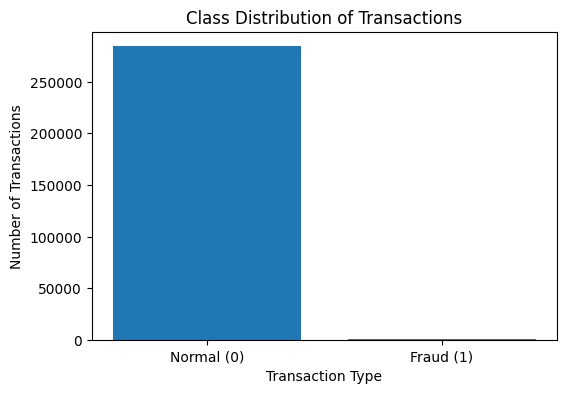

In [11]:
# ---------------------------------------------
# STEP 2: CHECK CLASS DISTRIBUTION
# ---------------------------------------------

print(df['Class'].value_counts())

# VISUALIZATION 1: Class Distribution Graph
# This shows imbalance

counts = df['Class'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Normal (0)', 'Fraud (1)'], counts)

plt.title("Class Distribution of Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [12]:
# ---------------------------------------------
# STEP 3: SPLIT FEATURES AND TARGET
# ---------------------------------------------

X = df.drop('Class', axis=1)
y = df['Class']

In [13]:
# ---------------------------------------------
# STEP 4: TRAIN-TEST SPLIT
# ---------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# ---------------------------------------------
# STEP 5: HANDLE IMBALANCE USING SMOTE
# ---------------------------------------------

smote = SMOTE(sampling_strategy=0.3, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Random Forest Training Time: 139.7795286178589 seconds
Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



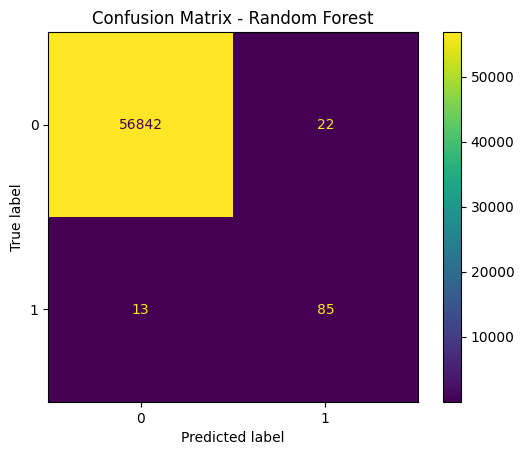

In [15]:
# ---------------------------------------------
# STEP 6: RANDOM FOREST MODEL
# ---------------------------------------------

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

import time

start = time.time()
rf.fit(X_train_resampled, y_train_resampled)
end = time.time()

print("Random Forest Training Time:", end - start, "seconds")

rf_pred = rf.predict(X_test)

# classification_report() not works with missing data, This is why we removed
# missing data after loading data above

print("Random Forest:\n", classification_report(y_test, rf_pred))

# VISUALIZATION 2: Confusion Matrix (Random Forest)

cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

SVM Training Time: 0.46340012550354004 seconds
SVM:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.44      0.54        98

    accuracy                           1.00     56962
   macro avg       0.85      0.72      0.77     56962
weighted avg       1.00      1.00      1.00     56962



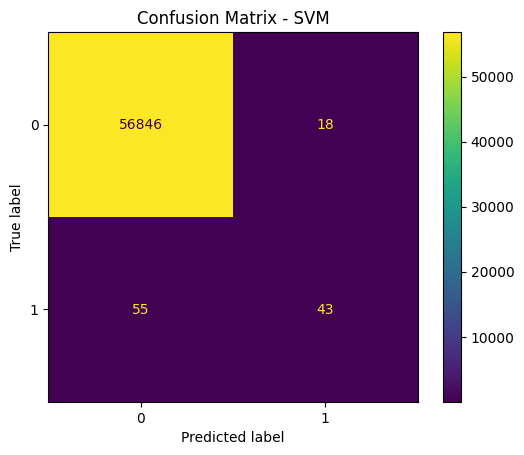

In [17]:
# ---------------------------------------------
# STEP 7: SVM MODEL (FAST VERSION)
# ---------------------------------------------

from sklearn.svm import LinearSVC

# Use smaller sample for speed
X_small = X_train_resampled[:50000]
y_small = y_train_resampled[:50000]

svm = LinearSVC(random_state=42)

start = time.time()
svm.fit(X_small, y_small)
end = time.time()

print("SVM Training Time:", end - start, "seconds")

svm_pred = svm.predict(X_test)

print("SVM:\n", classification_report(y_test, svm_pred))

# VISUALIZATION 3: Confusion Matrix (SVM)

cm_svm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

XGBoost Training Time: 13.037605285644531 seconds
XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



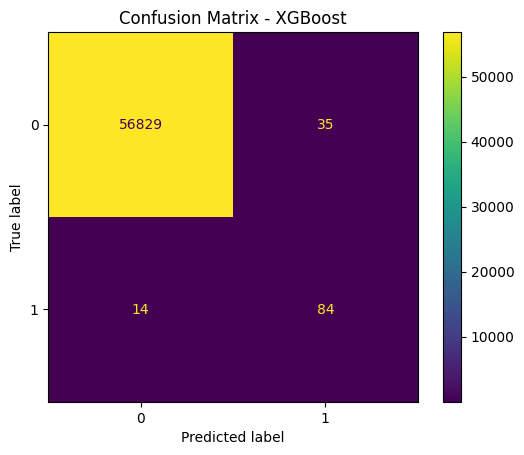

In [18]:
# ---------------------------------------------
# STEP 8: XGBOOST MODEL
# ---------------------------------------------

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric='logloss'
)

start = time.time()
xgb.fit(X_train_resampled, y_train_resampled)
end = time.time()

print("XGBoost Training Time:", end - start, "seconds")

xgb_pred = xgb.predict(X_test)

print("XGBoost:\n", classification_report(y_test, xgb_pred))

# VISUALIZATION 4: Confusion Matrix (XGBoost)

cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot()

plt.title("Confusion Matrix - XGBoost")
plt.show()

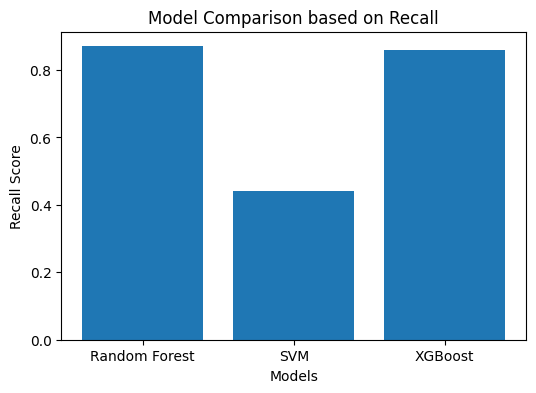

In [19]:
# ---------------------------------------------
# STEP 9: MODEL COMPARISON GRAPH
# ---------------------------------------------

# Recall values (from your results)
models = ['Random Forest', 'SVM', 'XGBoost']
recall_scores = [0.87, 0.44, 0.86]  # update if your values differ

plt.figure(figsize=(6,4))
plt.bar(models, recall_scores)

plt.title("Model Comparison based on Recall")
plt.xlabel("Models")
plt.ylabel("Recall Score")

plt.show()